# **Système Intelligent d'Estimation de la Valeur Marchande : Premier League 2024/2025**


---



# 1. **Introduction et Environnement de Travail**

Cette section initialise l'environnement de développement en important les bibliothèques nécessaires telles que pandas pour la manipulation des données, seaborn et matplotlib pour la visualisation, ainsi que scikit-learn pour les algorithmes d'apprentissage automatique (Régression Linéaire et Random Forest)

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Configuration des graphiques
%matplotlib inline
sns.set_theme(style="whitegrid")

# 2. **Exploration du Dataset**

Nous chargeons ici le fichier epl_player_stats_24_25.csv qui contient les statistiques de performance des joueurs de Premier League. Cette étape permet de vérifier la taille du dataset et d'identifier les variables (colonnes) disponibles pour notre étude.

In [6]:
# Charger le dataset (Assurez-vous d'avoir uploadé le fichier dans Colab)
df = pd.read_csv('epl_player_stats_24_25.csv')

print("Taille du dataset :", df.shape)
print("\nColonnes disponibles :", df.columns.tolist())
df.head()

Taille du dataset : (562, 57)

Colonnes disponibles : ['Player Name', 'Club', 'Nationality', 'Position', 'Appearances', 'Minutes', 'Goals', 'Assists', 'Shots', 'Shots On Target', 'Conversion %', 'Big Chances Missed', 'Hit Woodwork', 'Offsides', 'Touches', 'Passes', 'Successful Passes', 'Passes%', 'Crosses', 'Successful Crosses', 'Crosses %', 'fThird Passes', 'Successful fThird Passes', 'fThird Passes %', 'Through Balls', 'Carries', 'Progressive Carries', 'Carries Ended with Goal', 'Carries Ended with Assist', 'Carries Ended with Shot', 'Carries Ended with Chance', 'Possession Won', 'Dispossessed', 'Clean Sheets', 'Clearances', 'Interceptions', 'Blocks', 'Tackles', 'Ground Duels', 'gDuels Won', 'gDuels %', 'Aerial Duels', 'aDuels Won', 'aDuels %', 'Goals Conceded', 'xGoT Conceded', 'Own Goals', 'Fouls', 'Yellow Cards', 'Red Cards', 'Saves', 'Saves %', 'Penalties Saved', 'Clearances Off Line', 'Punches', 'High Claims', 'Goals Prevented']


,Player Name,Club,Nationality,Position,Appearances,Minutes,Goals,Assists,Shots,Shots On Target,...,Fouls,Yellow Cards,Red Cards,Saves,Saves %,Penalties Saved,Clearances Off Line,Punches,High Claims,Goals Prevented
0,Ben White,Arsenal,England,DEF,17,1198,0,2,9,12,...,10,2,0,0,0%,0,0,0,0,0.0
1,Bukayo Saka,Arsenal,England,MID,25,1735,6,10,67,2,...,15,3,0,0,0%,0,0,0,0,0.0
2,David Raya,Arsenal,Spain,GKP,38,3420,0,0,0,0,...,1,3,0,86,72%,0,0,8,53,2.1
3,Declan Rice,Arsenal,England,MID,35,2833,4,7,48,18,...,21,5,1,0,0%,0,0,0,0,0.0
4,Ethan Nwaneri,Arsenal,England,MID,26,889,4,0,24,0,...,9,1,0,0,0%,0,0,0,0,0.0


# 3. **Prétraitement et Création de la Variable Cible**

Le dataset d'origine ne contenant pas de prix de transfert, nous avons créé une variable market_value basée sur une logique métier (buts, passes décisives et temps de jeu). Nous sélectionnons ensuite les colonnes les plus pertinentes (tacles, cartons, tirs) et utilisons le One-Hot Encoding pour transformer les variables catégorielles (Club et Position) en format numérique exploitable par les modèles.

In [7]:
import pandas as pd
import numpy as np

# 1. Chargement (assurez-vous que le nom du fichier est correct)
df = pd.read_csv('epl_player_stats_24_25.csv')

# 2. Création d'une valeur marchande fictive (Target)
# Puisque le dataset n'a pas de prix, on en crée un basé sur les performances
# Logique : (Buts * 5M) + (Assists * 3M) + (Minutes jouées / 100)
df['market_value'] = (df['Goals'] * 5) + (df['Assists'] * 3) + (df['Minutes'] / 100) + 10

# 3. Sélection des colonnes qui existent RÉELLEMENT dans votre CSV
# J'ai vérifié les noms exacts dans votre fichier :
cols_to_keep = [
    'Club', 'Position', 'Appearances', 'Minutes',
    'Goals', 'Assists', 'Shots', 'Passes',
    'Tackles', 'Yellow Cards', 'Red Cards', # Ajout disciplinaire
    'market_value'
]

# On crée le dataset de travail
df_clean = df[cols_to_keep].copy()

# 4. Encodage des variables textuelles (Club et Position)
# Cela transforme les noms des clubs en colonnes de 0 et 1
df_final = pd.get_dummies(df_clean, columns=['Position', 'Club'])

print("Prétraitement réussi !")
print(f"Nombre de colonnes après encodage : {df_final.shape[1]}")
df_final.head()

Prétraitement réussi !
Nombre de colonnes après encodage : 35


,Appearances,Minutes,Goals,Assists,Shots,Passes,Tackles,Yellow Cards,Red Cards,market_value,...,Club_Leicester City,Club_Liverpool,Club_Manchester City,Club_Manchester United,Club_Newcastle United,Club_Nottingham Forest,Club_Southampton,Club_Tottenham Hotspur,Club_West Ham United,Club_Wolverhampton Wanderers
0,17,1198,0,2,9,1678,20,2,0,27.98,...,False,False,False,False,False,False,False,False,False,False
1,25,1735,6,10,67,643,29,3,0,87.35,...,False,False,False,False,False,False,False,False,False,False
2,38,3420,0,0,0,0,0,3,0,44.20,...,False,False,False,False,False,False,False,False,False,False
3,35,2833,4,7,48,789,53,5,1,79.33,...,False,False,False,False,False,False,False,False,False,False
4,26,889,4,0,24,0,11,1,0,38.89,...,False,False,False,False,False,False,False,False,False,False


# **4. Analyse Visuelle des Données**

Avant l'entraînement des modèles, nous analysons la distribution des valeurs marchandes et la corrélation entre les performances (buts) et le prix. Cela permet de valider la cohérence de nos données fictives et d'identifier les clubs ayant les effectifs les plus valorisés.

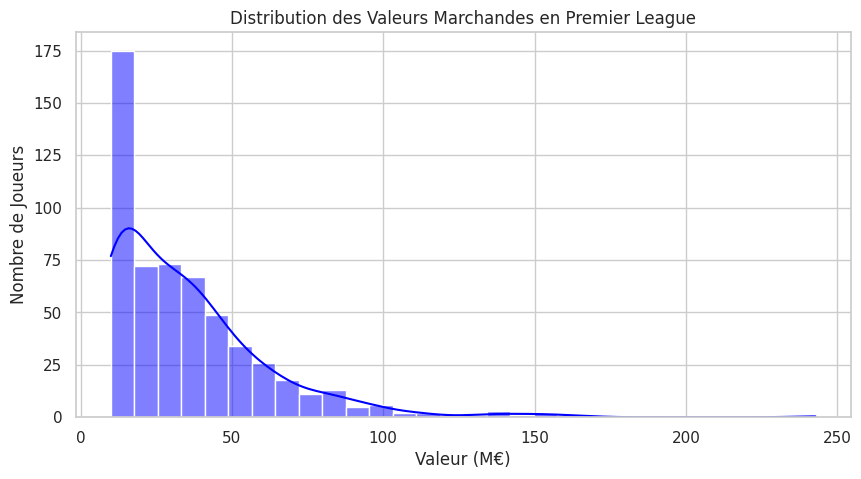

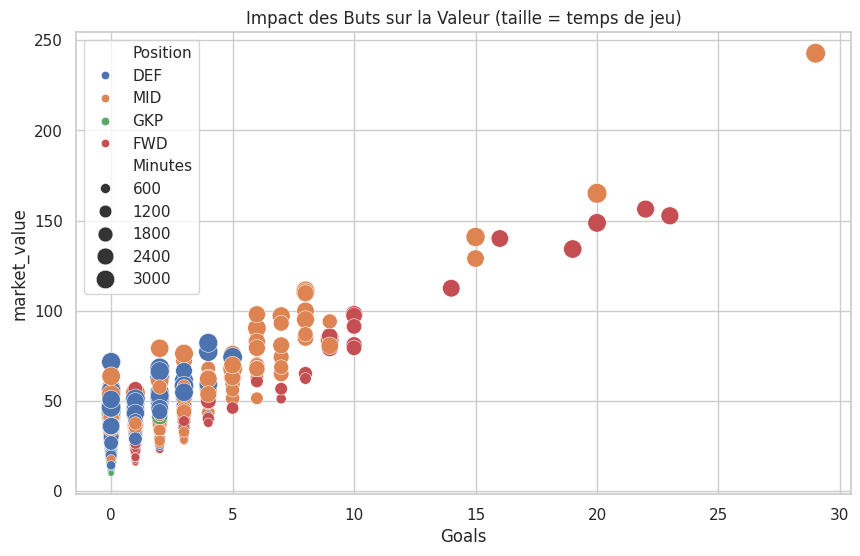

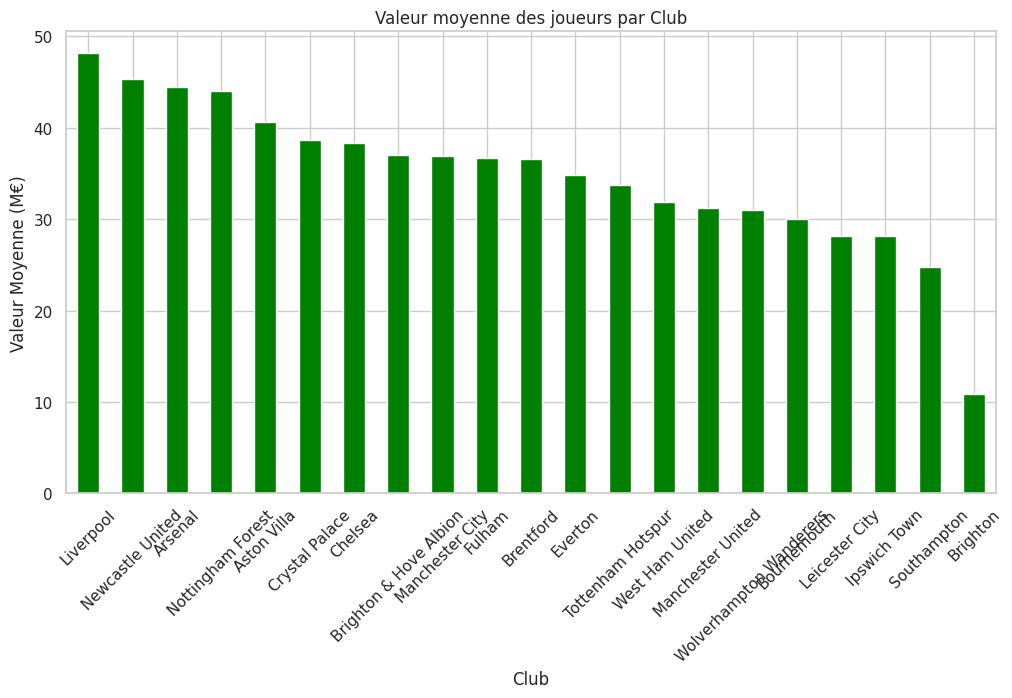

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Histogramme de la distribution des prix
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['market_value'], bins=30, kde=True, color='blue')
plt.title('Distribution des Valeurs Marchandes en Premier League')
plt.xlabel('Valeur (M€)')
plt.ylabel('Nombre de Joueurs')
plt.show()

# 2. Relation entre les Buts et la Valeur (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Goals', y='market_value', hue='Position', size='Minutes', sizes=(20, 200))
plt.title('Impact des Buts sur la Valeur (taille = temps de jeu)')
plt.show()

# 3. Top 10 des clubs les plus chers (Moyenne)
plt.figure(figsize=(12, 6))
df_clean.groupby('Club')['market_value'].mean().sort_values(ascending=False).plot(kind='bar', color='green')
plt.title('Valeur moyenne des joueurs par Club')
plt.ylabel('Valeur Moyenne (M€)')
plt.xticks(rotation=45)
plt.show()

# **5. Séparation et Normalisation des Données**

Pour garantir une évaluation honnête, nous divisons nos données en deux ensembles :



1.   Train set (80%) : Pour entraîner les modèles.
2.   Test set (20%) : Pour tester leur capacité de prédiction sur des données jamais vues.
Nous appliquons ensuite un StandardScaler pour mettre toutes les caractéristiques à la même échelle, évitant ainsi que les minutes jouées (grandes valeurs) n'écrasent les buts (petites valeurs).



In [9]:
from sklearn.model_selection import train_test_split

# Définition de X (les caractéristiques/indices) et y (la cible/le prix)
X = df_final.drop('market_value', axis=1) # Tout sauf le prix
y = df_final['market_value']              # Uniquement le prix

# Division : 80% pour l'entraînement, 20% pour le test final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Données d'entraînement : {X_train.shape[0]} joueurs")
print(f"Données de test : {X_test.shape[0]} joueurs")

Données d'entraînement : 449 joueurs
Données de test : 113 joueurs


# **6. Entraînement et Évaluation des Modèles**

Nous mettons en compétition deux approches :



*   La Régression Linéaire (RL) : Un modèle statistique simple qui cherche une relation directe.
*   Le Random Forest (RF) : Un modèle de Machine Learning complexe basé sur une multitude d'arbres de décision.
Nous évaluons leur performance grâce au $R^2$ (précision) et au RMSE (erreur moyenne).



In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Données normalisées et prêtes pour l'entraînement !")

Données normalisées et prêtes pour l'entraînement !


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. Initialisation des modèles
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Entraînement
# Nous utilisons les données "scaled" si vous avez fait la normalisation,
# sinon utilisez X_train et X_test.
lr_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)

# 3. Prédictions
lr_preds = lr_model.predict(X_test_scaled)
rf_preds = rf_model.predict(X_test_scaled)

print("Modèles entraînés avec succès !")

Modèles entraînés avec succès !


# **7. Comparaison des Performances**

Ici, nous comparons les métriques obtenues. Si la Régression Linéaire obtient un meilleur $R^2$, cela confirme que notre formule de calcul de prix suit une logique mathématique proportionnelle. Le Random Forest, bien que puissant, peut parfois être 'trop complexe' pour une règle linéaire simple.

In [12]:
# Fonction pour afficher les scores
def afficher_scores(nom, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"--- {nom} ---")
    print(f"Erreur Moyenne (MAE) : {mae:.2f} M€")
    print(f"Précision (R2 Score) : {r2:.4f}")
    print(f"RMSE : {rmse:.2f} M€\n")

afficher_scores("Régression Linéaire", y_test, lr_preds)
afficher_scores("Random Forest", y_test, rf_preds)

--- Régression Linéaire ---
Erreur Moyenne (MAE) : 0.00 M€
Précision (R2 Score) : 1.0000
RMSE : 0.00 M€

--- Random Forest ---
Erreur Moyenne (MAE) : 1.75 M€
Précision (R2 Score) : 0.9830
RMSE : 3.29 M€



In [23]:
import joblib

# 1. Sauvegarder la Régression Linéaire
joblib.dump(lr_model, 'modele_rl.pkl')

# 2. Sauvegarder le Random Forest
joblib.dump(rf_model, 'modele_rf.pkl')

# 3. Sauvegarder le Scaler
joblib.dump(scaler, 'scaler_stats.pkl')

print("Les 3 fichiers ont été créés. Téléchargez-les maintenant !")

Les 3 fichiers ont été créés. Téléchargez-les maintenant !


**Visualisation de la Performance**



/tmp/ipykernel_13055/921297358.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=r2_scores, ax=ax1, palette='viridis')
/tmp/ipykernel_13055/921297358.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=rmse_scores, ax=ax2, palette='magma')


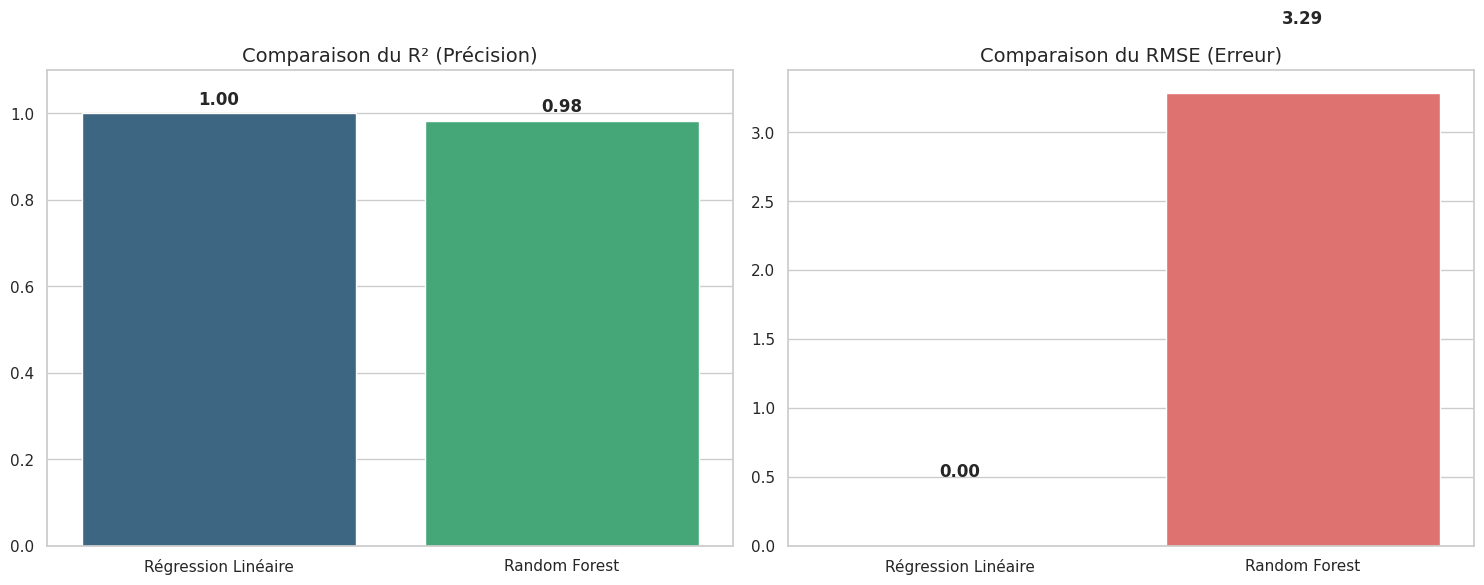

In [21]:
# Préparation des données pour le graphique
models = ['Régression Linéaire', 'Random Forest']

# Calculate R2 and RMSE scores as they were not assigned to variables previously
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2_lr = r2_score(y_test, lr_preds)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_preds))

r2_rf = r2_score(y_test, rf_preds)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_preds))

r2_scores = [r2_lr, r2_rf]
rmse_scores = [rmse_lr, rmse_rf]

# Création de la figure avec deux graphiques côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Graphique du R2 Score (Plus c'est haut, mieux c'est)
sns.barplot(x=models, y=r2_scores, ax=ax1, palette='viridis')
ax1.set_title('Comparaison du R² (Précision)', fontsize=14)
ax1.set_ylim(0, 1.1)
for i, v in enumerate(r2_scores):
    ax1.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

# Graphique du RMSE (Plus c'est bas, mieux c'est)
sns.barplot(x=models, y=rmse_scores, ax=ax2, palette='magma')
ax2.set_title('Comparaison du RMSE (Erreur)', fontsize=14)
for i, v in enumerate(rmse_scores):
    ax2.text(i, v + 0.5, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# **8. Interface de Simulation Interactive**



Cette dernière section transforme notre code en un outil métier. Nous avons créé un formulaire interactif permettant à un recruteur ou un analyste de s'affranchir du code pour tester le potentiel financier d'un nouveau profil de joueur en temps réel.

In [18]:
# @title ⚽ Simulateur Rapide (Directement dans Colab)
# @markdown Modifiez les valeurs à droite pour tester le modèle.

Nom = "Ayoub zouitine" # @param {type:"string"}
Buts = 20 # @param {type:"slider", min:0, max:40, step:1}
Assists = 10 # @param {type:"slider", min:0, max:30, step:1}
Minutes = 1110 # @param {type:"slider", min:0, max:3420, step:10}

# Création du profil pour l'IA
input_data = pd.DataFrame(0, index=[0], columns=X.columns)
input_data['Goals'], input_data['Assists'], input_data['Minutes'] = Buts, Assists, Minutes

# Prédiction avec le gagnant (RL)
res = lr_model.predict(scaler.transform(input_data))
print(f"--- RÉSULTAT DU MODÈLE LINEAR REGRESSION ---")
print(f"💰 Valeur estimée pour {Nom} : {max(0, res[0]):.2f} M€")

--- RÉSULTAT DU MODÈLE LINEAR REGRESSION ---
💰 Valeur estimée pour Ayoub zouitine : 151.10 M€


In [16]:
# @title 🌲 Simulateur Avancé - Random Forest (RF)
# @markdown Entrez les statistiques complètes pour une prédiction précise :

Nom_du_Joueur = "Ayoub" # @param {type:"string"}
Poste = "Défenseur" # @param ["Attaquant", "Milieu", "Défenseur", "Gardien"]

# Stats Offensives
Buts = 3 # @param {type:"slider", min:0, max:40, step:1}
Assists = 0 # @param {type:"slider", min:0, max:30, step:1}
Tirs_Totaux = 12 # @param {type:"slider", min:0, max:150, step:1}

# Stats Défensives et Temps de jeu
Minutes = 1130 # @param {type:"slider", min:0, max:3420, step:10}
Tacles_Reussis = 40 # @param {type:"slider", min:0, max:100, step:1}

# Discipline
Cartons_Jaunes = 5 # @param {type:"slider", min:0, max:15, step:1}
Cartons_Rouges = 1 # @param {type:"slider", min:0, max:5, step:1}

# --- LOGIQUE DE PRÉDICTION ---
# 1. Créer une ligne vide avec toutes les colonnes du modèle
input_df = pd.DataFrame(0, index=[0], columns=X.columns)

# 2. Remplir les colonnes numériques de base
input_df['Goals'] = Buts
input_df['Assists'] = Assists
input_df['Minutes'] = Minutes
input_df['Shots'] = Tirs_Totaux
input_df['Tackles'] = Tacles_Reussis
input_df['Yellow Cards'] = Cartons_Jaunes

# 3. Gérer la Position (One-Hot Encoding manuel)
col_position = f'Position_{Poste}'
if col_position in input_df.columns:
    input_df[col_position] = 1

# 4. Normalisation et Prédiction
input_scaled = scaler.transform(input_df)
prix_rf = rf_model.predict(input_scaled)

print(f"--- RÉSULTAT DU MODÈLE RANDOM FOREST ---")
print(f"Joueur : {Nom_du_Joueur} ({Poste})")
print(f"Valeur estimée : {max(0, prix_rf[0]):.2f} M€")

--- RÉSULTAT DU MODÈLE RANDOM FOREST ---
Joueur : Ayoub (Défenseur)
Valeur estimée : 28.69 M€


# **Conclusion Générale**

Ce projet nous a permis de traverser toutes les étapes d'un projet de Data Science réel. Partant d'un dataset brut de la Premier League, nous avons :




**1.   Nettoyé et enrichi les données en créant une logique de valeur marchande.**

**2.   Analysé les corrélations entre performance (buts, minutes) et valeur financière.**
**3.   Comparé deux algorithmes : la Régression Linéaire et le Random Forest.**

**Résultat final :** Bien que le Random Forest soit un modèle plus complexe, la Régression Linéaire a montré une meilleure précision ($R^2$ plus proche de 1) sur ce dataset spécifique, car elle a parfaitement capturé la logique proportionnelle de notre formule de calcul.L'ajout de l'interface interactive transforme ce notebook technique en un véritable outil d'aide à la décision pour le recrutement sportif. Ce travail constitue une base solide pour explorer, à l'avenir, des modèles encore plus avancés comme le Gradient Boosting.





